# **Eşikleme, İkili Sisteme Dönüştürme  ve Uyarlanabilir Eşikleme**

####**Bu derste şunları öğreneceğiz:**
1. İkiye Bölünmüş Görüntüler
2. Eşikleme Yöntemleri
3. Uyarlanabilir Eşikleme
4. SkImage'ın Yerel Eşiği

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

### **Eşikleme Yöntemleri**

<img src="tresholding.jpg" widhth="300">

https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html

## Kullanım
retval, dst = cv2.threshold(src, thresh, maxval, type)
## Parametreler
* src -> Girdi görüntüsü.
    * Genellikle 8-bit tek kanallı (grayscale) bir görüntü olur.
* thresh -> Eşik değeri.
    * Piksel değerinin bu değerden büyük veya küçük olmasına göre işlem yapılır.
    * Örneğin, 127 verilirse, 127’den büyük pikseller farklı, küçük pikseller farklı işlenir.
* maxval-> Eşik değerini geçen piksellere atanacak değer.
    * Genellikle 255 (beyaz) veya başka bir değer verilebilir.
* type -> Eşikleme tipi.
    * cv2.THRESH_BINARY → Piksel ≥ thresh → maxval, aksi halde 0
    * cv2.THRESH_BINARY_INV → Piksel ≥ thresh → 0, aksi halde maxval
    * cv2.THRESH_TRUNC → Piksel ≥ thresh → thresh, aksi halde aynı değer kalır
    * cv2.THRESH_TOZERO → Piksel ≥ thresh → aynı kalır, aksi halde 0
    * cv2.THRESH_TOZERO_INV → Piksel ≥ thresh → 0, aksi halde aynı değer kalır

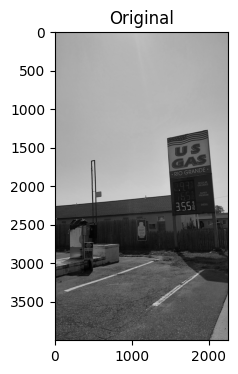

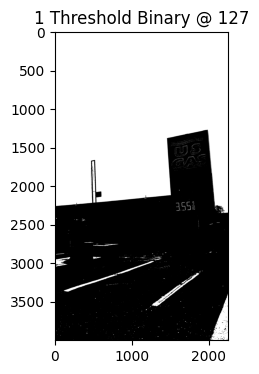

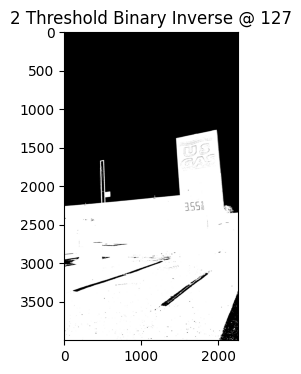

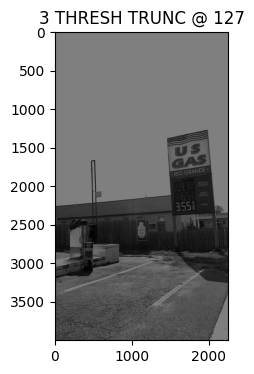

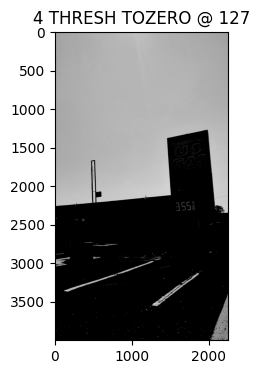

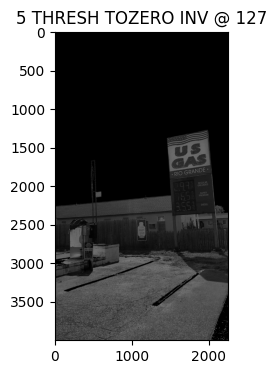

In [3]:
image = cv2.imread('../files/images/america8.jpg',0)
imshow("Original", image,4)
ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
imshow('1 Threshold Binary @ 127', thresh1,4)
ret,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
imshow('2 Threshold Binary Inverse @ 127', thresh2,4)
ret,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
imshow('3 THRESH TRUNC @ 127', thresh3,4)
ret,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
imshow('4 THRESH TOZERO @ 127', thresh4,4)
ret,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
imshow('5 THRESH TOZERO INV @ 127', thresh5,4)

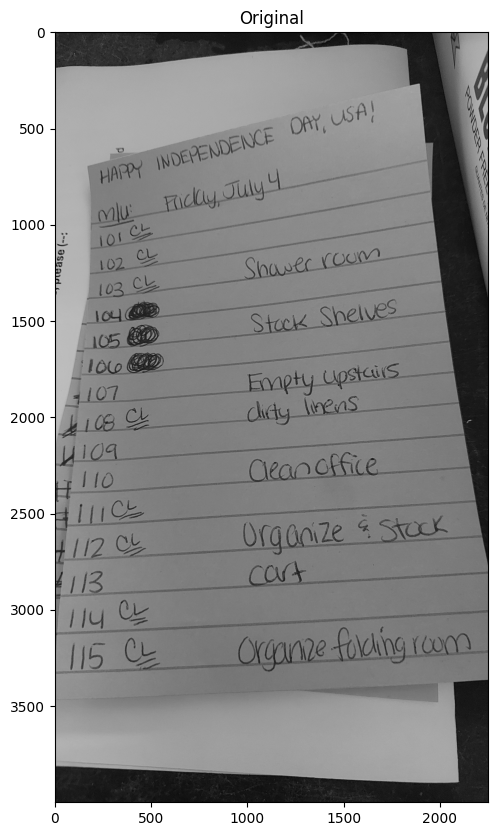

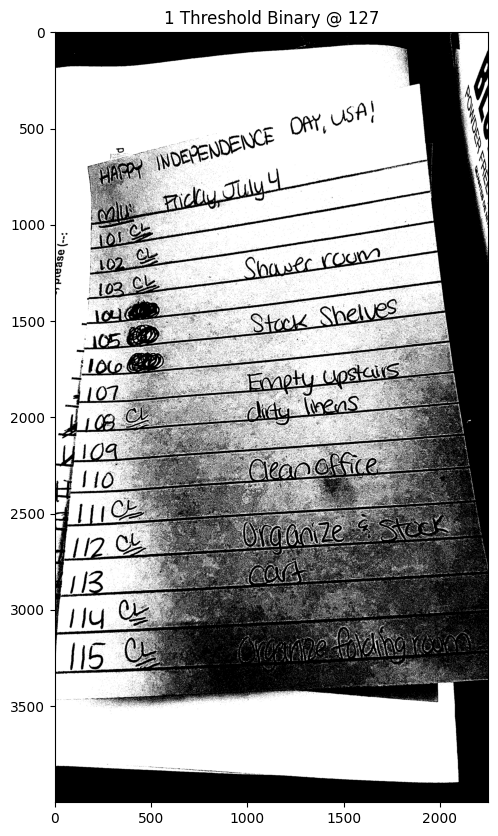

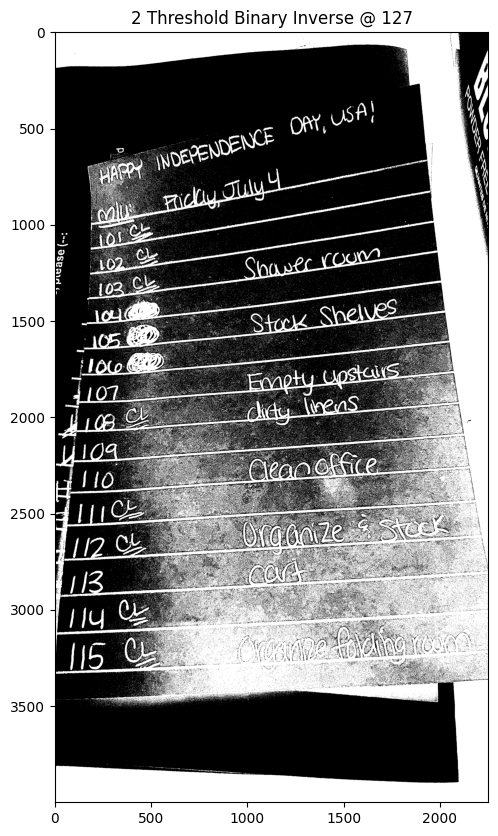

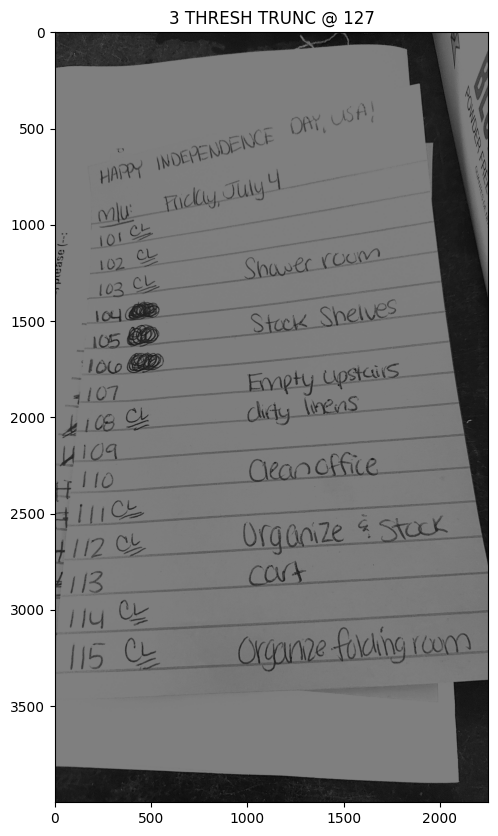

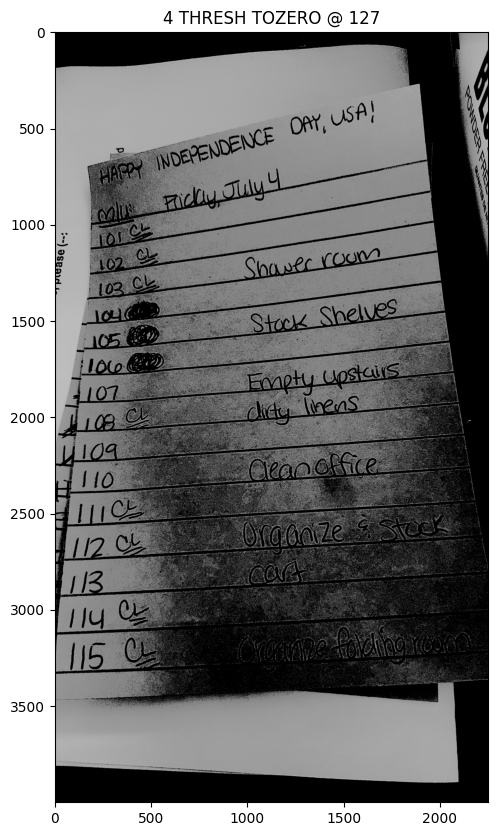

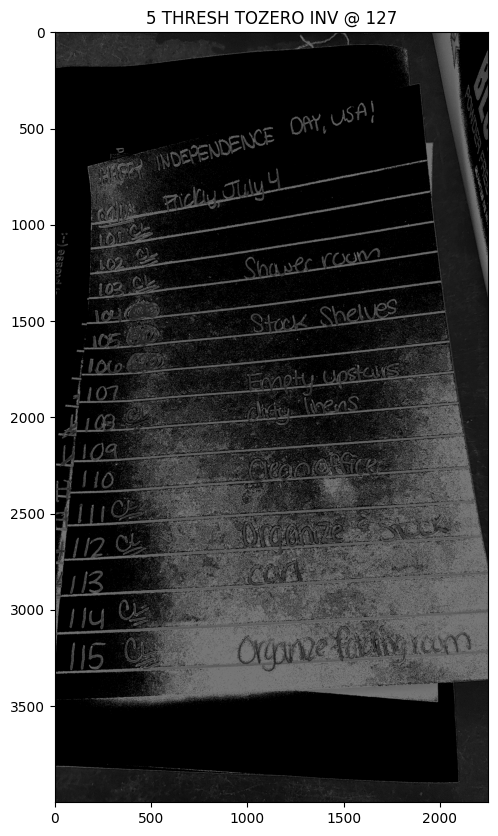

In [4]:
# Resmimizi gri tonlamalı olarak yükle
image = cv2.imread('../files/images/america9.jpg',0)
imshow("Original", image)

# 127'nin altındaki değerler 0'a veya siyaha gider, üstündeki her şey 255'e (beyaz) gider
ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
imshow('1 Threshold Binary @ 127', thresh1)

# 127'nin altındaki değerler 255'e ve 127'nin üzerindeki değerler 0'a gider (yukarıdakinin tersi)
ret,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
imshow('2 Threshold Binary Inverse @ 127', thresh2)

# 127'nin üzerindeki değerler 127'de kesilir (tutulur) (255 bağımsız değişkeni kullanılmaz)
ret,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
imshow('3 THRESH TRUNC @ 127', thresh3)

# 127'nin altındaki değerler 0'a gider, 127'nin üzerindeki değerler değişmez
ret,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
imshow('4 THRESH TOZERO @ 127', thresh4)

# Yukarıdakinin tersi, 127'nin altı değişmez, 127'nin üstü 0'a gider
ret,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
imshow('5 THRESH TOZERO INV @ 127', thresh5)

#### **Adaptif Eşikleme**
İki farklı yöntem kullanılacaktır:
1. ADAPTIVE_THRESH_MEAN_C
2. THRESH_OTSU

#### **cv2.adaptiveThreshold**
Kullanım:
``*dst=cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)``
Parametreler:
- **dst** – src ile aynı boyutta ve aynı türde hedef görüntü.
- **src** – Kaynak 8 bit tek kanallı görüntü.
- **maxValue** – Eşikleme sonrası piksel değerinin alacağı maksimum değer. Genellikle 255 (beyaz) kullanılır.
- **adaptiveMethod** –Eşikleme için kullanılan iki yöntem:\
        * cv2.ADAPTIVE_THRESH_MEAN_C → Komşuluk penceresindeki ortalama değere göre eşik belirler\
        * cv2.ADAPTIVE_THRESH_GAUSSIAN_C → Komşuluk penceresindeki Gaussian ağırlıklı ortalama kullanır.\
- **thresholdType** – Eşikleme tipi: cv2.THRESH_BINARY → Piksel ≥ eşik → maxValue, aksi halde 0. cv2.THRESH_BINARY_INV → Piksel ≥ eşik → 0, aksi halde maxValue. Genellikle bunlar kullanılır. Ancak daha farklı da olabilir.
- **blockSize** – Komşuluk penceresinin boyutu. Tek sayı olmalı (3, 5, 7, …). Bu boyut kadar çevredeki piksellere bakılarak eşik değeri belirlenir.
- **C** – Hesaplanan eşik değerinden çıkarılacak sabit bir değer. Pozitif bir sayı ise eşik değeri azaltır, negatif ise artırır. Örneğin, C=2 ise eşik = ortalama - 2 veya Gaussian - 2 olur.


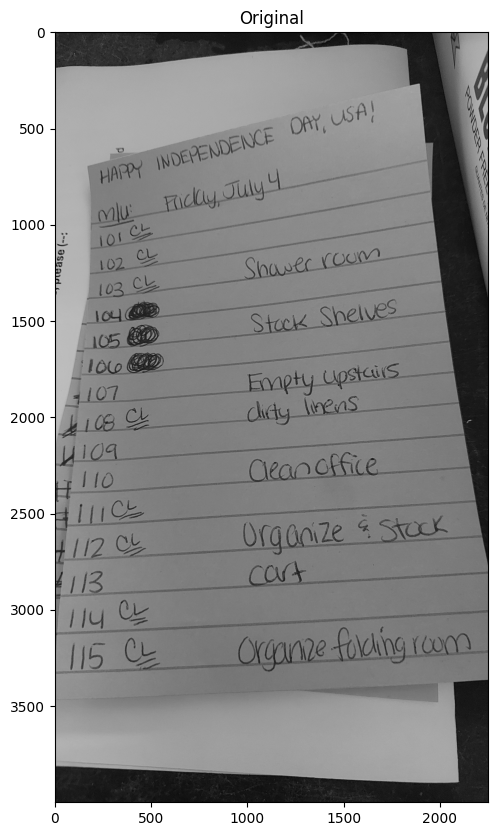

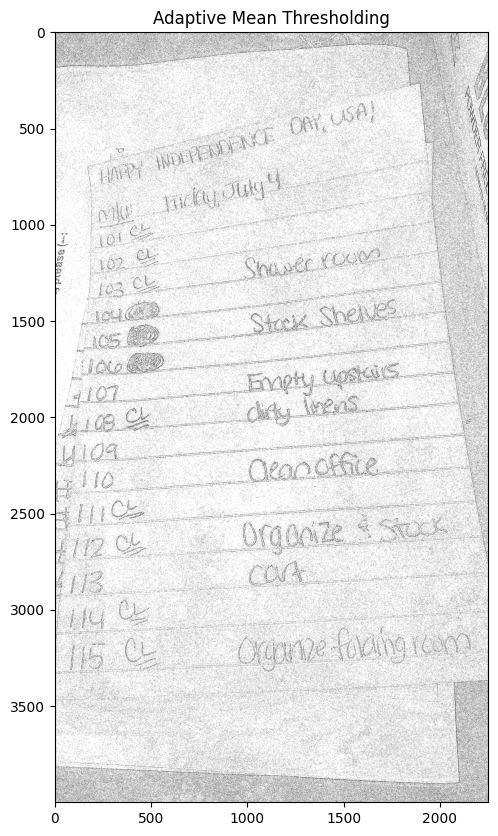

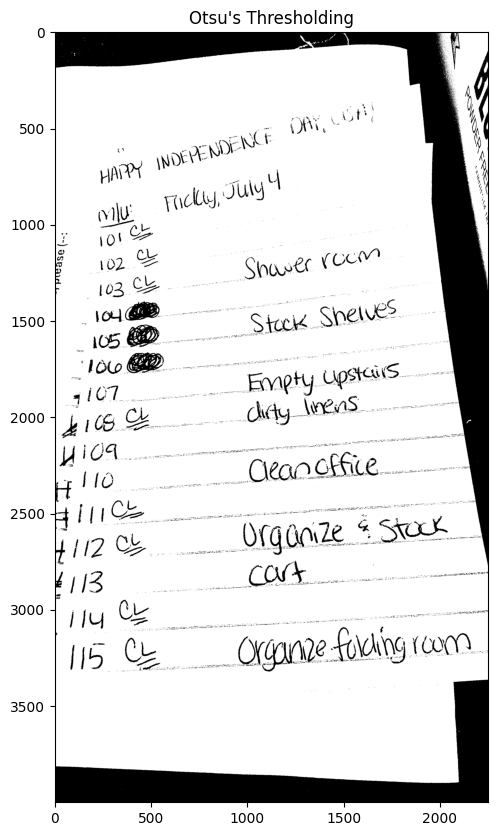

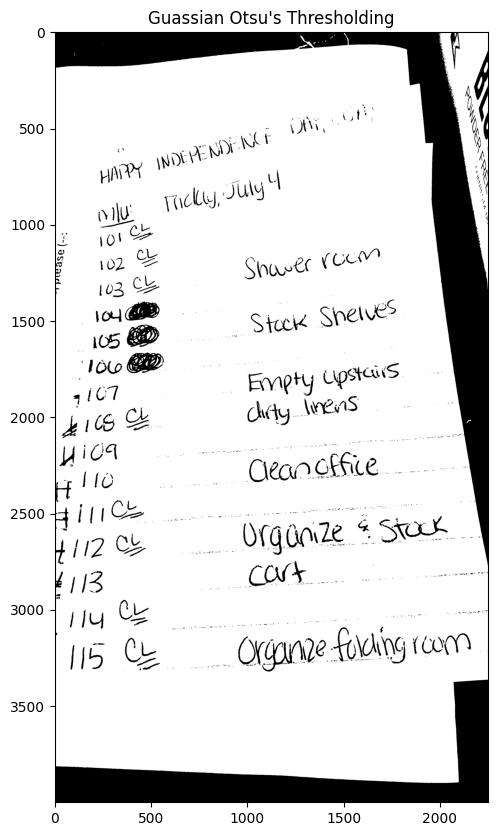

In [5]:
image = cv2.imread('../files/images/america9.jpg',0)
imshow("Original", image)

# AdaptiveThreshold Kullanımı
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, 5)
imshow("Adaptive Mean Thresholding", thresh)

#Otsu eşiklemesi
_, th2 = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Otsu's Thresholding", th2)

# Gauss filtrelemesinden sonra Otsu eşiklemesi
blur = cv2.GaussianBlur(image, (5,5), 0)
_, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Guassian Otsu's Thresholding", th3)

### **Skimage Eşiği Yerel**


``threshold_local(image, block_size, offset=10)``

threshold_local işlevi, her pikseli çevreleyen karakteristik bir ``block_size`` boyutuna sahip bölgelerdeki (yani yerel komşuluklar) eşikleri hesaplar. Her eşik değeri, yerel komşuluğun ağırlıklı ortalamasından bir ``offset`` değerinin çıkarılması ile bulunur.


https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding.html

In [6]:
# eğer bilgisayarınızda skimage kütüphanesi yüklü değilse
!pip install scikit-image

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/12.8 MB 5.6 MB/s eta 0:00:03
   --------- ------------------------------ 3.1/12.8 MB 6.8 MB/s eta 0:00:02
   --------------- ------------------------ 5.0/12.8 MB 7.2 MB/s eta 0:00:02
   -------------------- ------------------- 6.6/12.8 MB 7.3 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.8 MB 7.7 MB/s eta 0:00:01
   ------------------------------- -------- 10.2/12.8 MB 7.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.8 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 12.6 MB/s  0:00:00

   ---------------------------------------- 0/5 [tifffile]
   --------------------------------------

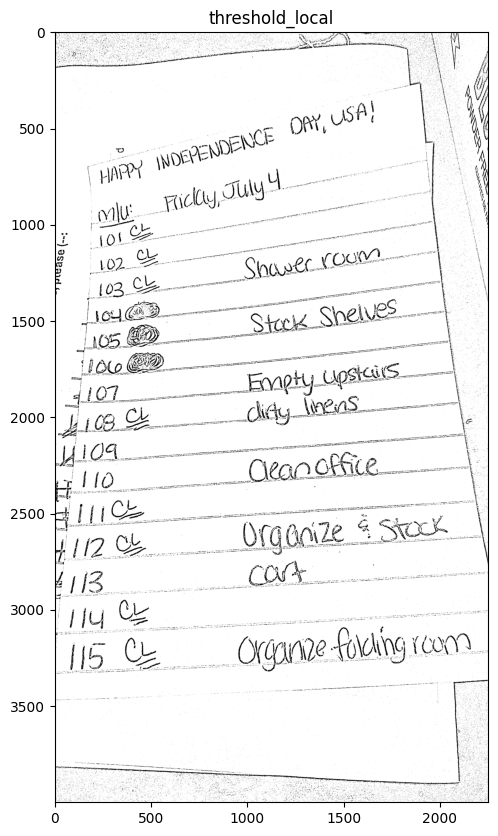

In [8]:
from skimage.filters import threshold_local

image = cv2.imread('../files/images/america9.jpg')

# Değer bileşenini HSV renk uzayından alıyoruz
# sonra uyarlamalı eşikleme uyguluyoruz
V = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))[2]
T = threshold_local(V, 25, offset=15, method="gaussian")
# cv2.cvtColor ile BGR → HSV dönüşümü yapılıyor.
# cv2.split ile H, S, V kanalları ayrılıyor.
# [2] ile V (value / parlaklık) kanalı seçiliyor.
# Neden? Adaptive threshold genellikle parlaklık bilgisini kullanır, renk değil.
#threshold_local fonksiyonu her piksel için yerel eşik değeri hesaplar.
#Parametreler:
# V → eşiklenecek gri tonlama görüntü.
# 25 → block_size, yani eşik hesaplamak için bakılacak komşuluk penceresi boyutu.
# offset=15 → Eşik değerinden çıkarılacak sabit sayı. Piksel > (ortalama - offset) ise beyaz.
# method="gaussian" → Gaussian ağırlıklı ortalama ile yerel eşikleme yapılacak.
# Çıktı T, her piksel için ayrı bir eşik değeri içerir.

# Eşik işlemini uygulayın
thresh = (V > T).astype("uint8") * 255
# thresh değişkeni artık binary bir görüntüdür:
# Beyaz → piksel parlaklığı yerel eşikten büyük
# Siyah → piksel parlaklığı yerel eşikten küçük
imshow("threshold_local", thresh)

### **Why Bluring is Important before Thresholding?**

## **Answer - Noise**

<img src="otsu.jpg" width="400">


https://docs.opencv.org/master/d9/d8b/tutorial_py_contours_hierarchy.html